# Network Topologies, Standardized Schema & Multi-Backend Visualization

**DeepBullwhip v0.3.0 Tutorial**

This notebook demonstrates the new v0.3.0 features:
1. **Network topologies** — define arbitrary DAG supply chains (serial, tree, convergent)
2. **JSON schema** — standardized interchange format for supply chain networks
3. **NetworkX integration** — graph algorithms and analysis
4. **Multi-backend rendering** — identical diagrams in matplotlib, Graphviz, and TikZ
5. **Publication themes** — kfupm, ieee, presentation, minimal

---

In [1]:
# --- Colab / Environment Setup ---
# Run this cell first if using Google Colab or a fresh environment.
import importlib, sys

if "google.colab" in sys.modules:
    print("Running on Google Colab -- installing deepbullwhip with extras...")
    get_ipython().system('pip install -q "deepbullwhip[network,viz]"')
elif importlib.util.find_spec("deepbullwhip") is None:
    print("deepbullwhip not found -- installing from local source...")
    get_ipython().system('pip install -q -e "..[network,viz]"')
else:
    print(f"deepbullwhip ready (v{__import__('deepbullwhip').__version__})")

deepbullwhip ready (v0.3.0)


In [2]:
import numpy as np
from deepbullwhip import (
    EchelonConfig, EdgeConfig, SupplyChainGraph, from_serial,
    NetworkSupplyChain, render_graph, to_json, from_json, save_json, load_json,
    get_theme, list_themes,
)
from deepbullwhip.chain.config import beer_game_config, consumer_2tier_config
from deepbullwhip.schema.definition import NodeLayoutHint, LayoutDefaults, NetworkMetadata
import matplotlib.pyplot as plt

print("Available themes:", list_themes())

Available themes: ['kfupm', 'ieee', 'presentation', 'minimal']


## 1. Supply Chain Topologies

### 1.1 Two-Tier Serial Chain (Manufacturer → Retailer)

Nodes: ['Retailer', 'Manufacturer']
Edges: [('Manufacturer', 'Retailer')]
Demand nodes: ['Retailer']
Source nodes: ['Manufacturer']


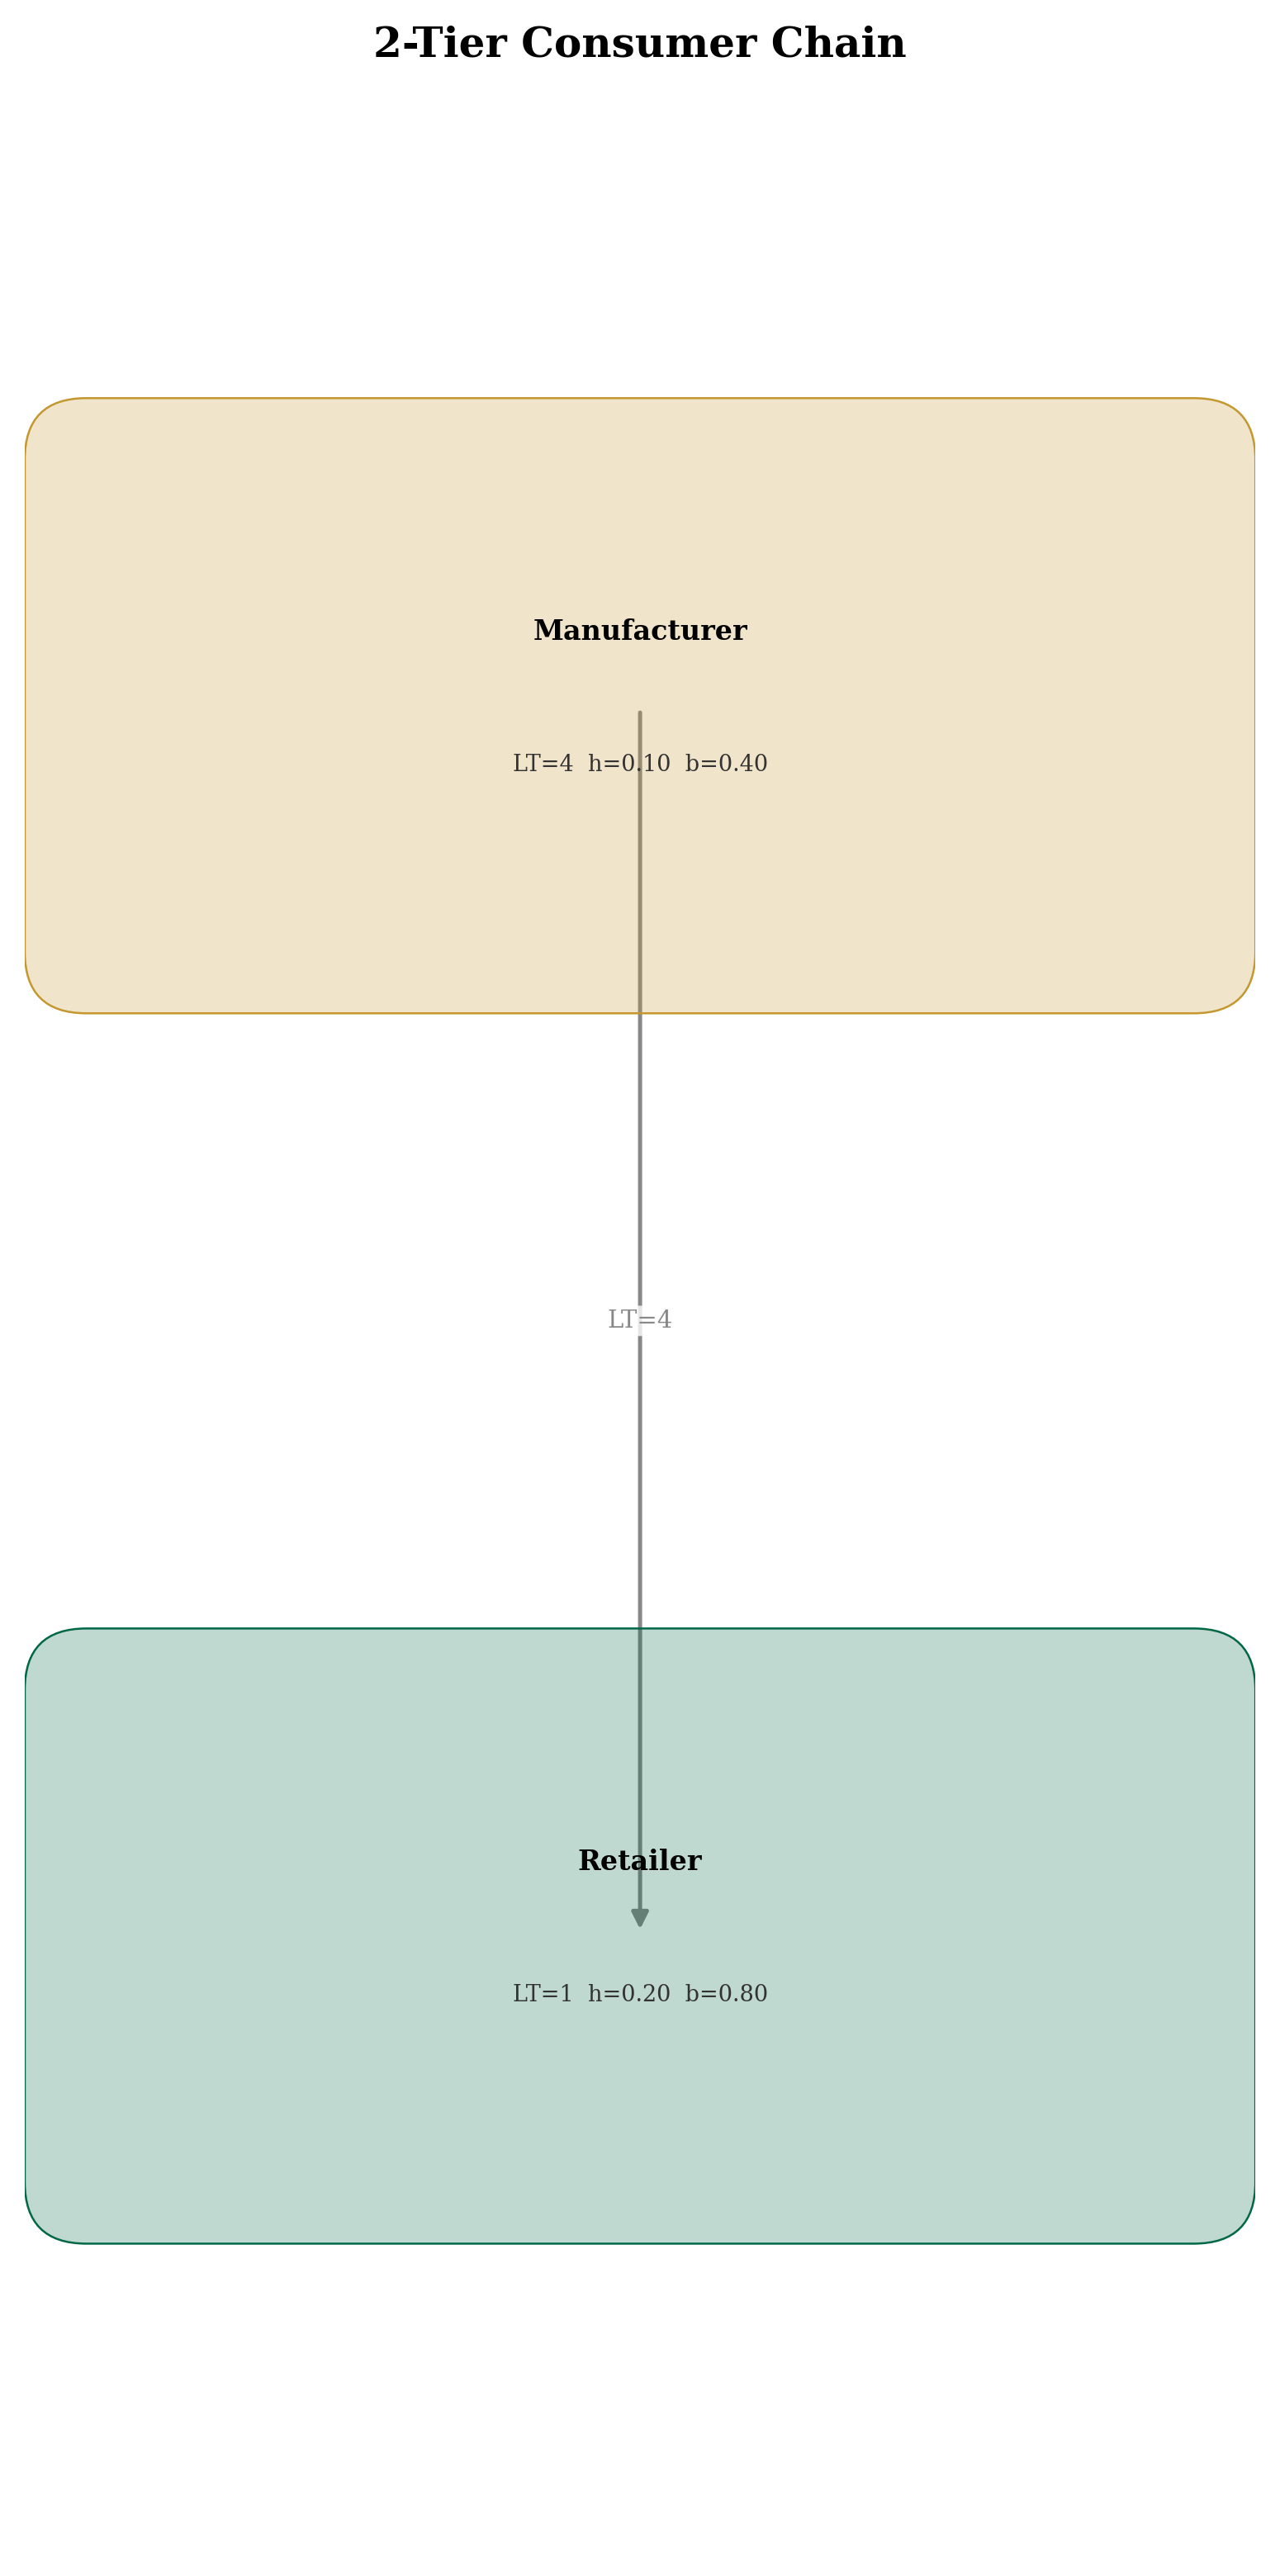

In [3]:
# 2-tier consumer goods chain
graph_2tier = from_serial(consumer_2tier_config())
print(f"Nodes: {list(graph_2tier.nodes.keys())}")
print(f"Edges: {list(graph_2tier.edges.keys())}")
print(f"Demand nodes: {graph_2tier.demand_nodes}")
print(f"Source nodes: {graph_2tier.source_nodes}")

fig = render_graph(graph_2tier, theme="kfupm", title="2-Tier Consumer Chain")
plt.show()

### 1.2 Four-Tier Beer Game (Factory → Distributor → Wholesaler → Retailer)

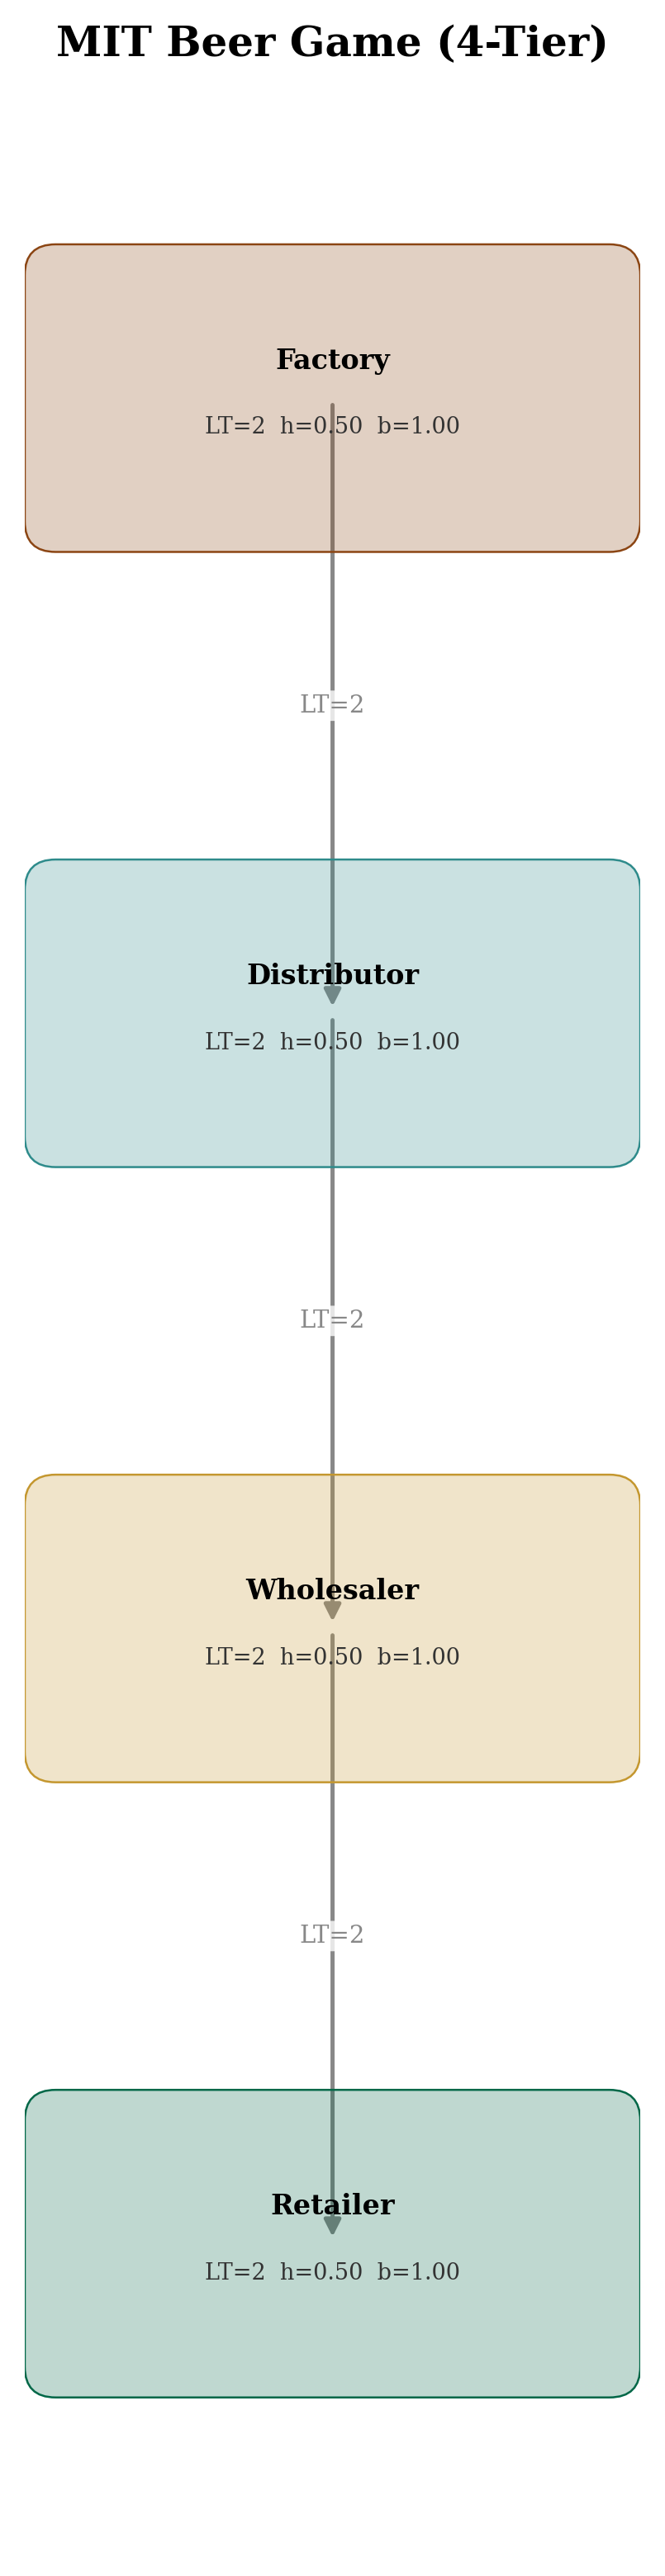

In [4]:
# 4-tier MIT Beer Game
graph_4tier = from_serial(beer_game_config())
fig = render_graph(graph_4tier, theme="kfupm", title="MIT Beer Game (4-Tier)")
plt.show()

### 1.3 Distribution Tree (Factory → Warehouse → {Store A, Store B})

Demand nodes: ['Store_A', 'Store_B']
Source nodes: ['Factory']
Topological order: ['Factory', 'Warehouse', 'Store_A', 'Store_B']


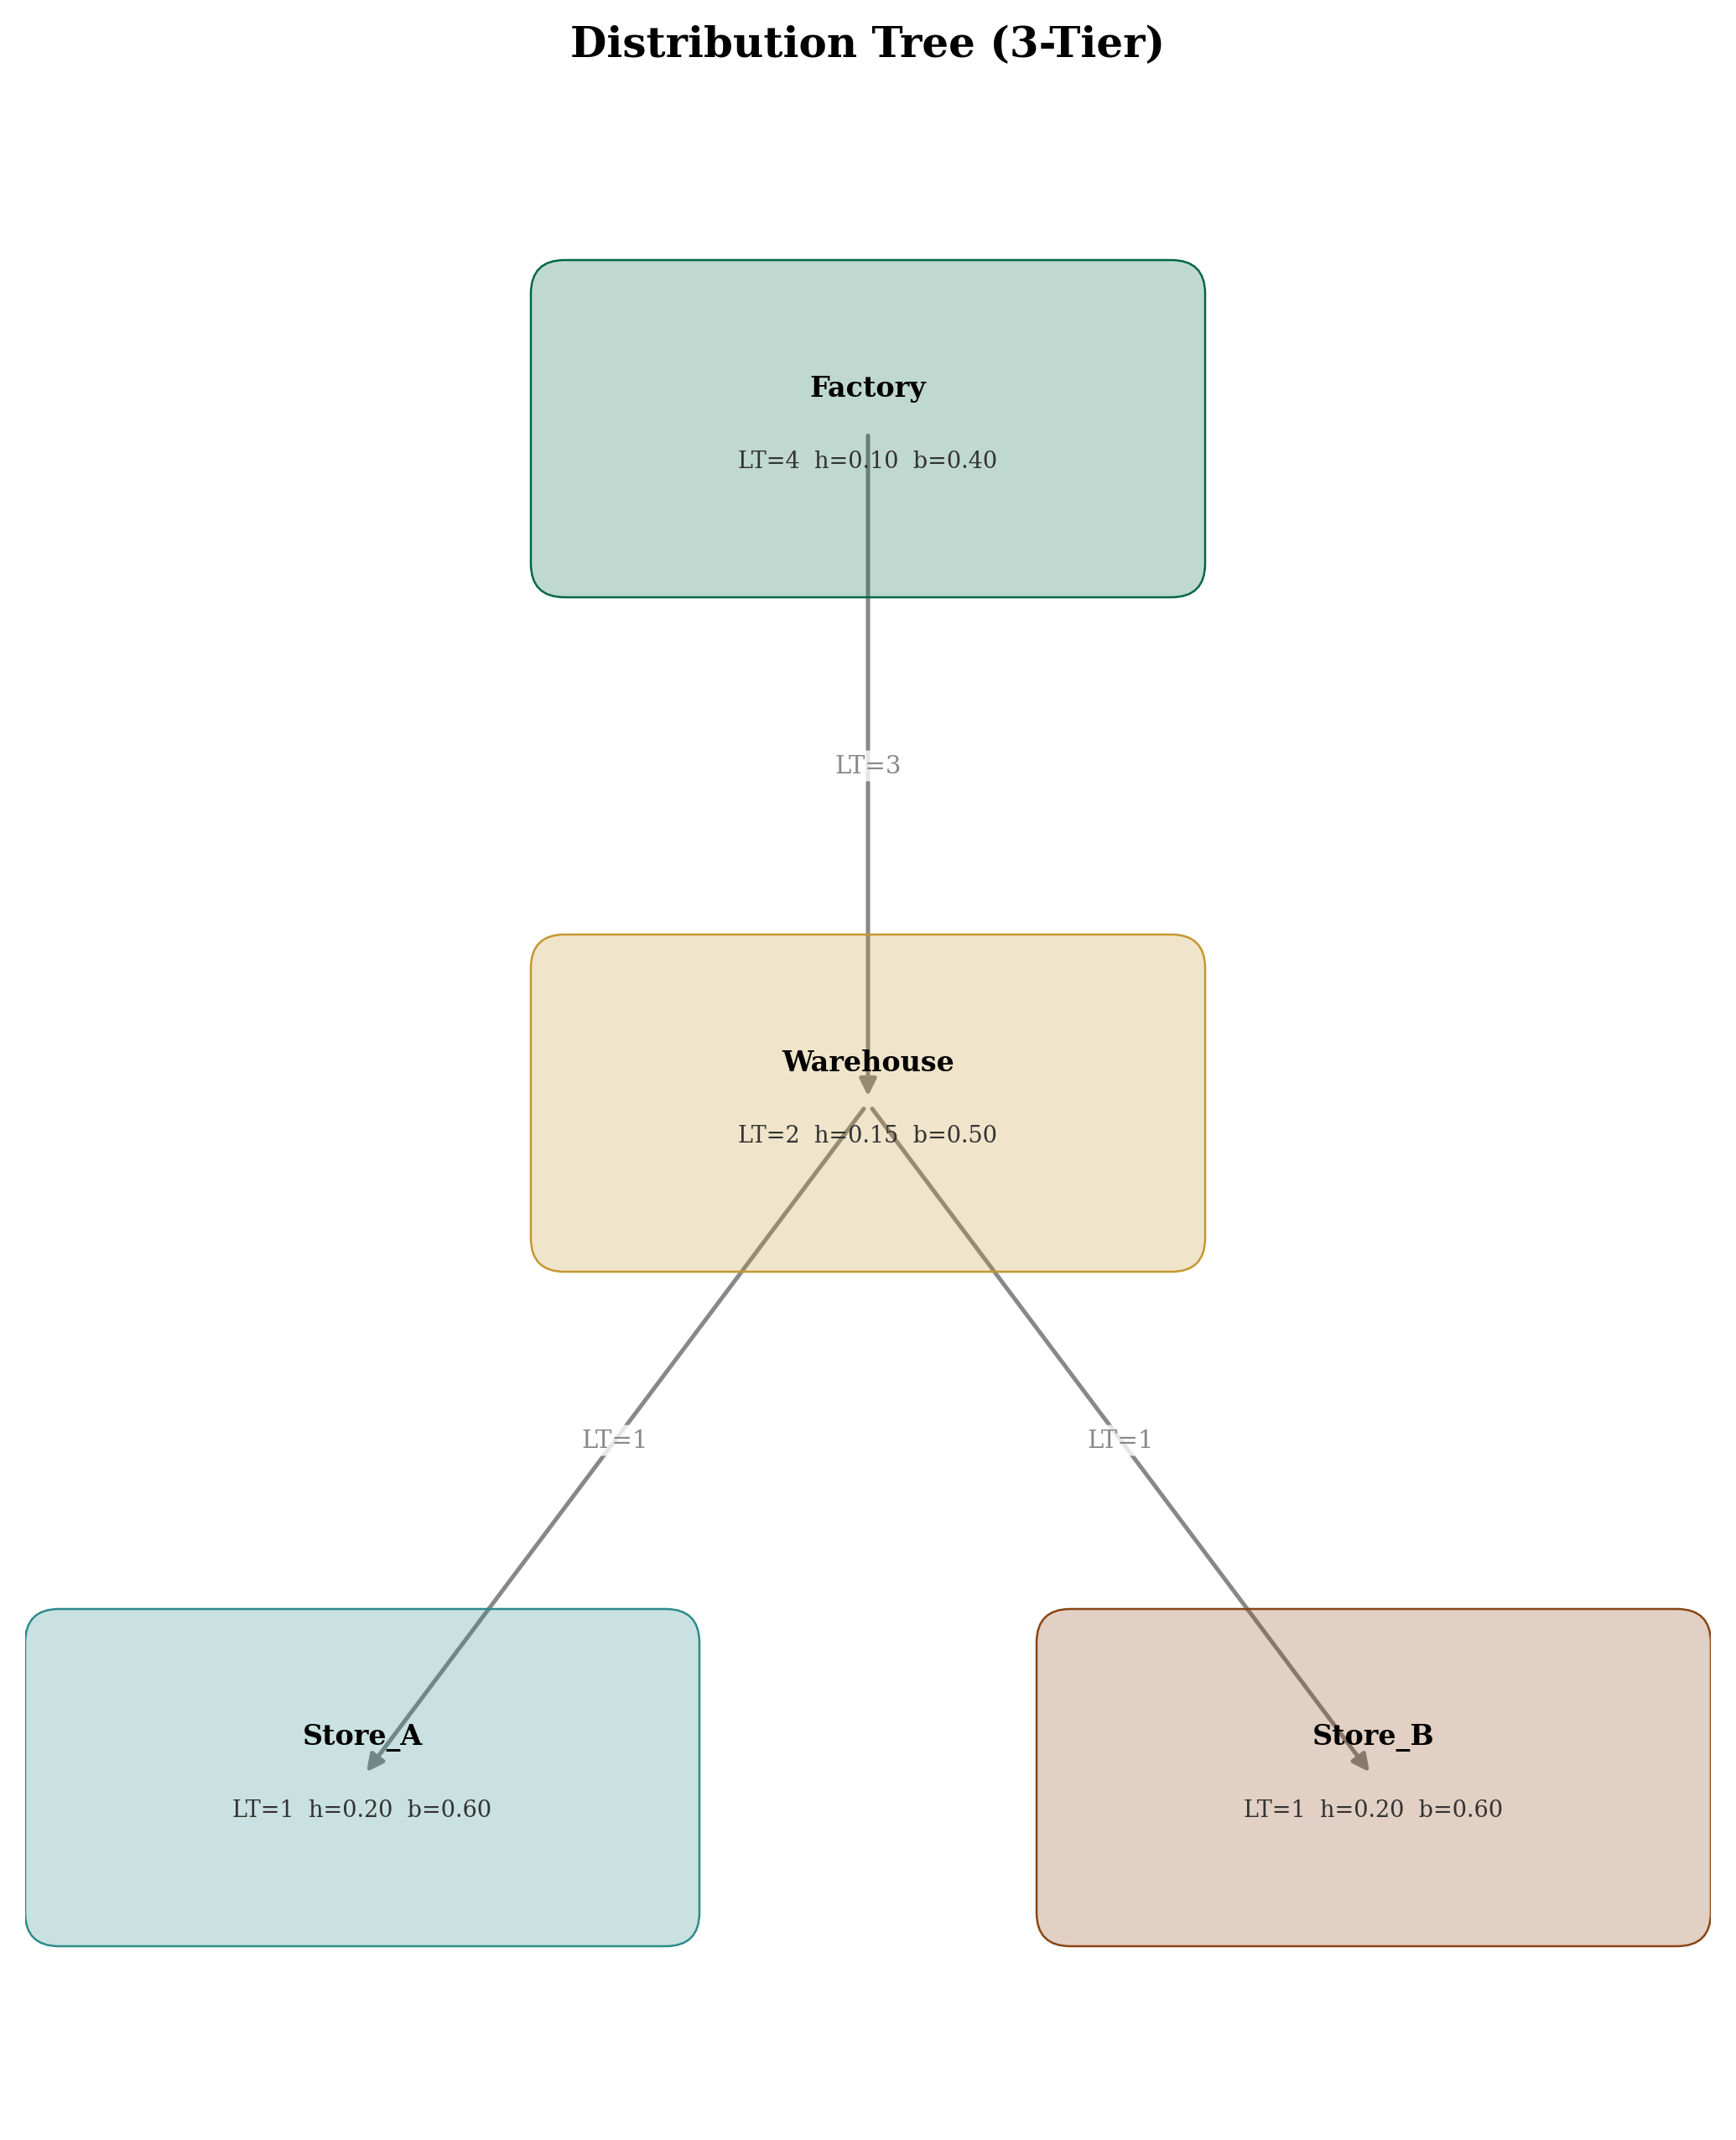

In [5]:
# Distribution tree with branching
tree = SupplyChainGraph(
    nodes={
        "Factory": EchelonConfig("Factory", lead_time=4, holding_cost=0.10, backorder_cost=0.40),
        "Warehouse": EchelonConfig("Warehouse", lead_time=2, holding_cost=0.15, backorder_cost=0.50),
        "Store_A": EchelonConfig("Store_A", lead_time=1, holding_cost=0.20, backorder_cost=0.60),
        "Store_B": EchelonConfig("Store_B", lead_time=1, holding_cost=0.20, backorder_cost=0.60),
    },
    edges={
        ("Factory", "Warehouse"): EdgeConfig(lead_time=3),
        ("Warehouse", "Store_A"): EdgeConfig(lead_time=1),
        ("Warehouse", "Store_B"): EdgeConfig(lead_time=1),
    },
)

print(f"Demand nodes: {tree.demand_nodes}")
print(f"Source nodes: {tree.source_nodes}")
print(f"Topological order: {tree.topological_order()}")

fig = render_graph(tree, theme="kfupm", title="Distribution Tree (3-Tier)")
plt.show()

### 1.4 Convergent Network (Two Suppliers → Assembler → Retailer)

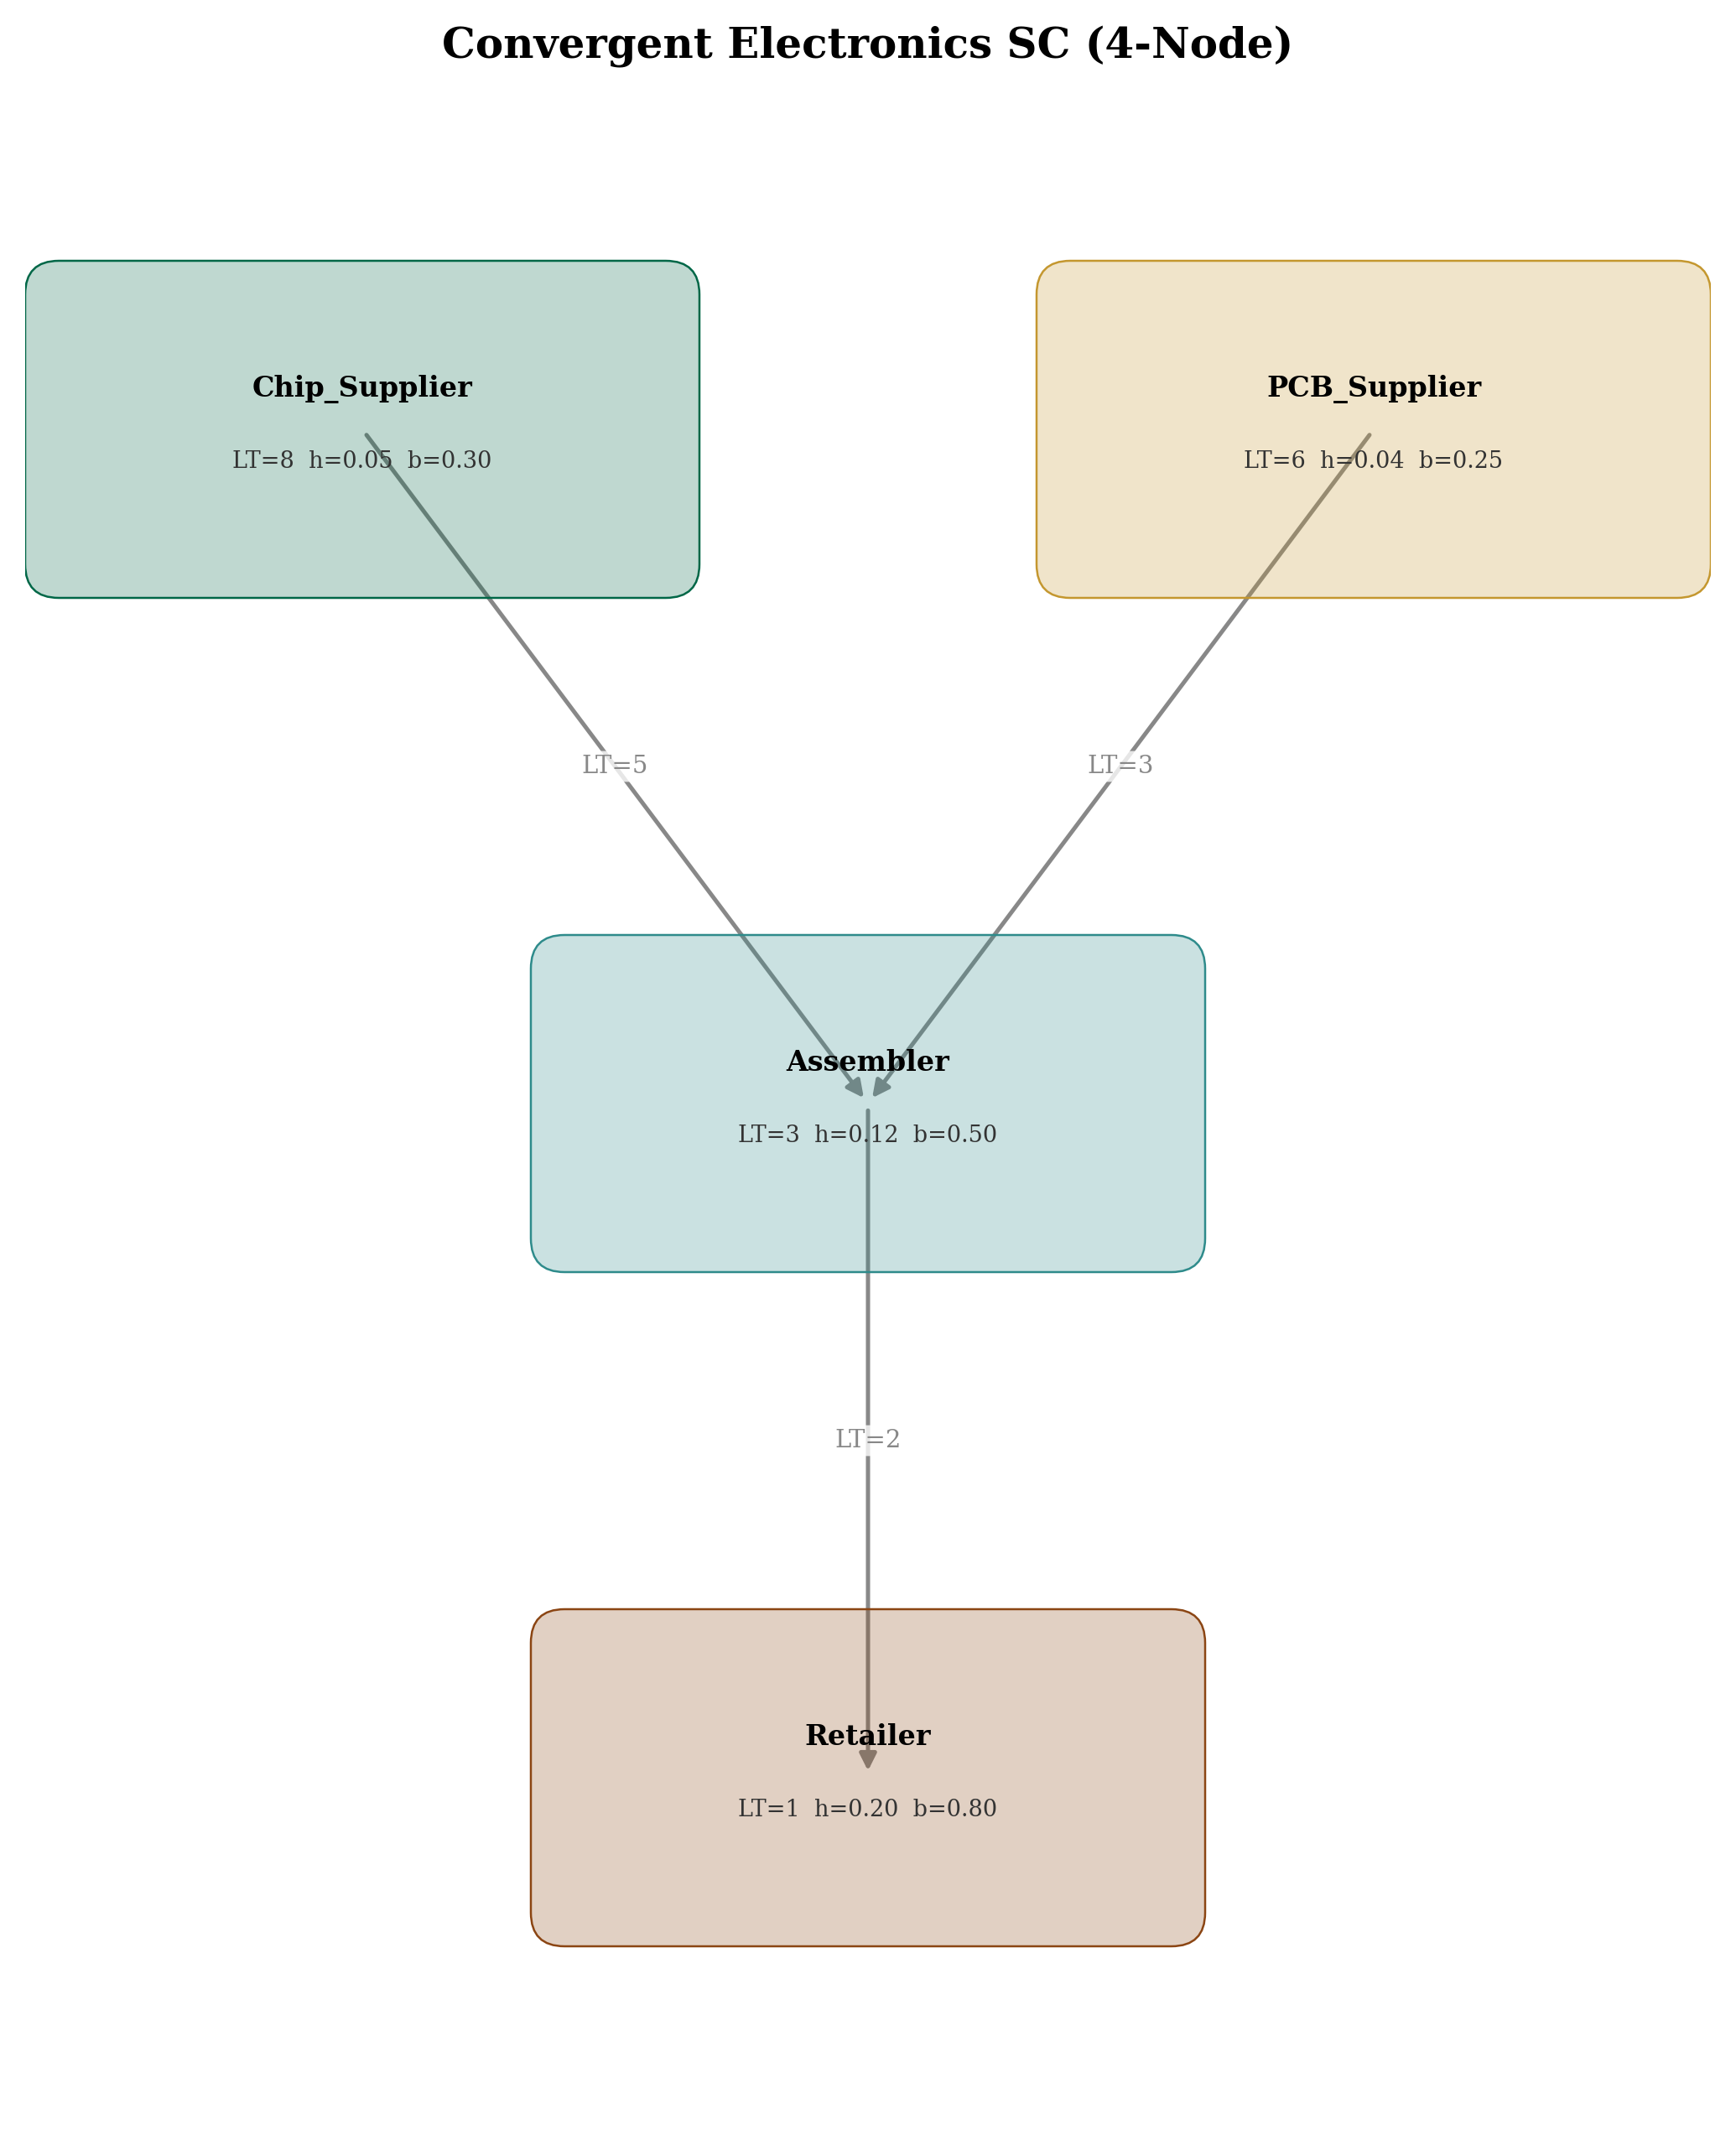

In [6]:
# Convergent network: two raw material suppliers feed into an assembler
convergent = SupplyChainGraph(
    nodes={
        "Chip_Supplier": EchelonConfig("Chip_Supplier", lead_time=8, holding_cost=0.05, backorder_cost=0.30),
        "PCB_Supplier": EchelonConfig("PCB_Supplier", lead_time=6, holding_cost=0.04, backorder_cost=0.25),
        "Assembler": EchelonConfig("Assembler", lead_time=3, holding_cost=0.12, backorder_cost=0.50),
        "Retailer": EchelonConfig("Retailer", lead_time=1, holding_cost=0.20, backorder_cost=0.80),
    },
    edges={
        ("Chip_Supplier", "Assembler"): EdgeConfig(lead_time=5),
        ("PCB_Supplier", "Assembler"): EdgeConfig(lead_time=3),
        ("Assembler", "Retailer"): EdgeConfig(lead_time=2),
    },
)

fig = render_graph(convergent, theme="kfupm", title="Convergent Electronics SC (4-Node)")
plt.show()

## 2. Publication Themes

Compare the same network rendered with all four built-in themes:

kfupm: serif 8.0pt, 7.0" wide, alpha=0.25


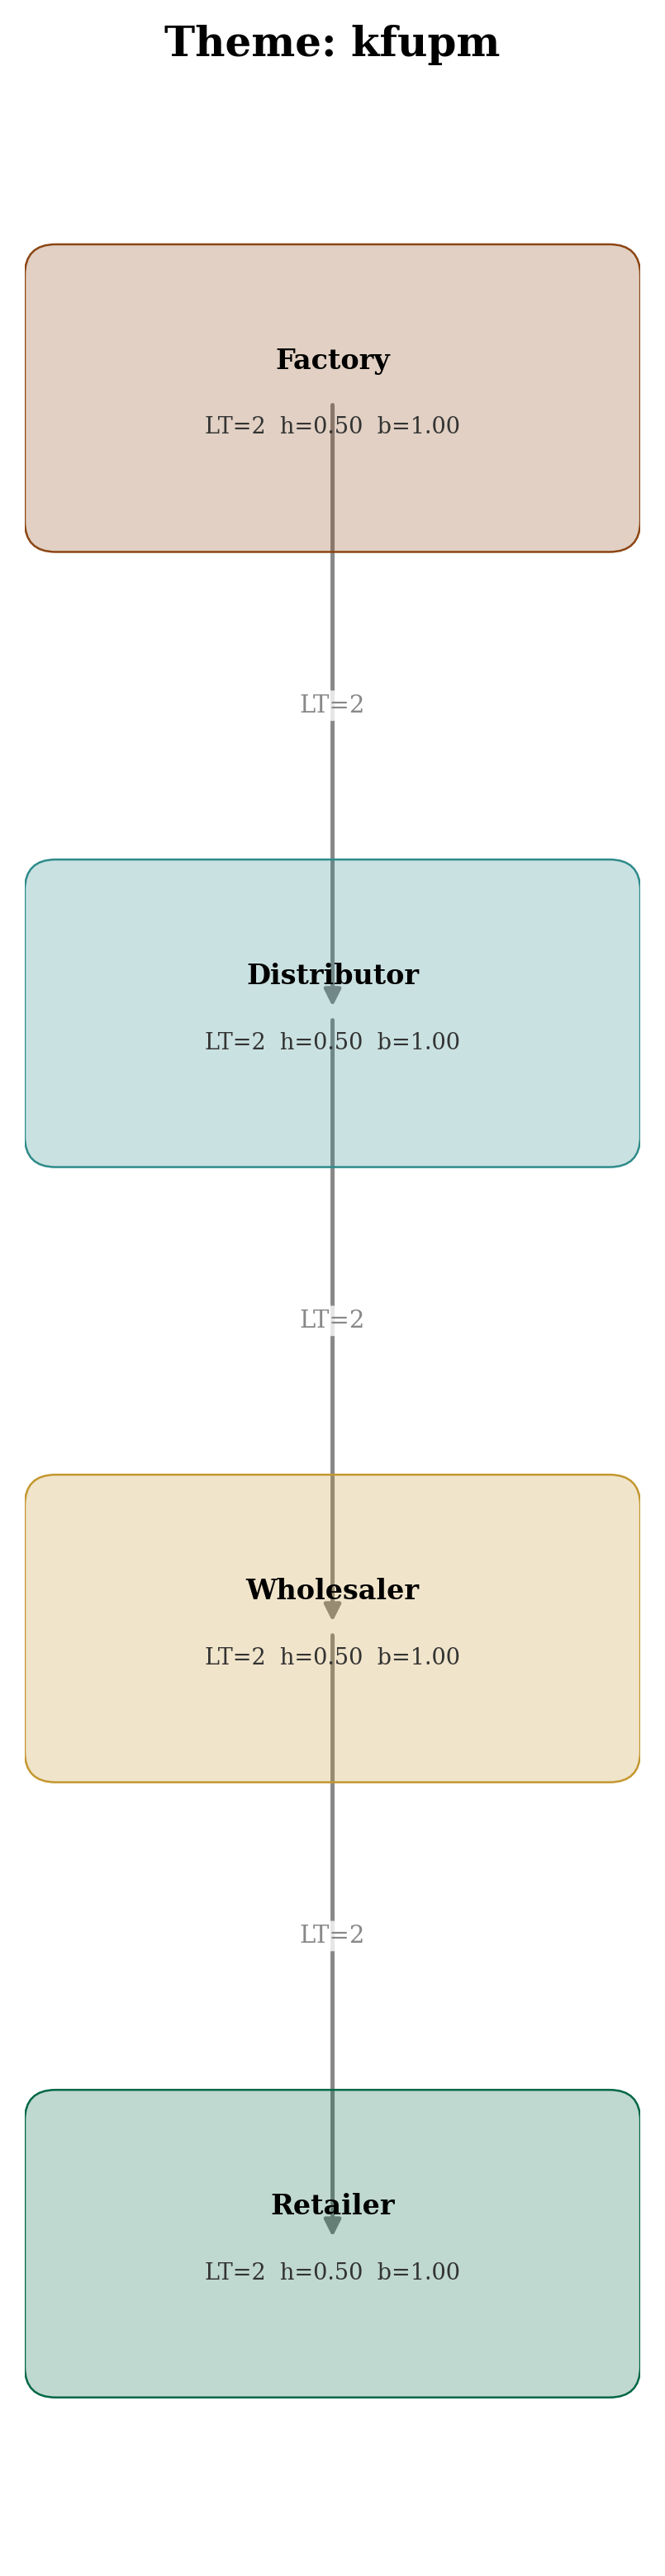

ieee: serif 7.0pt, 3.5" wide, alpha=0.15


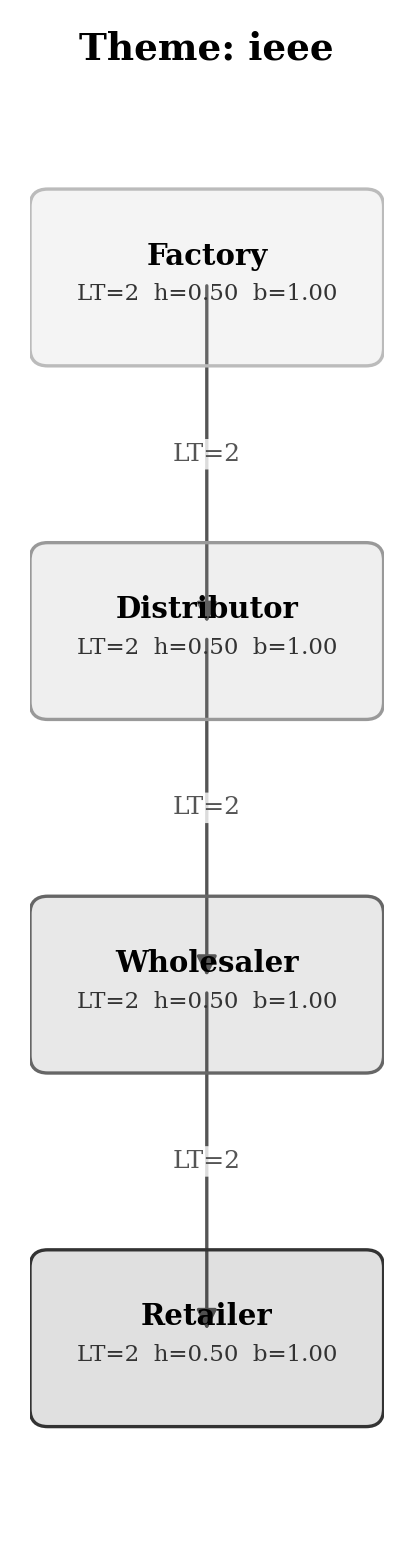

presentation: sans-serif 12.0pt, 10.0" wide, alpha=0.35


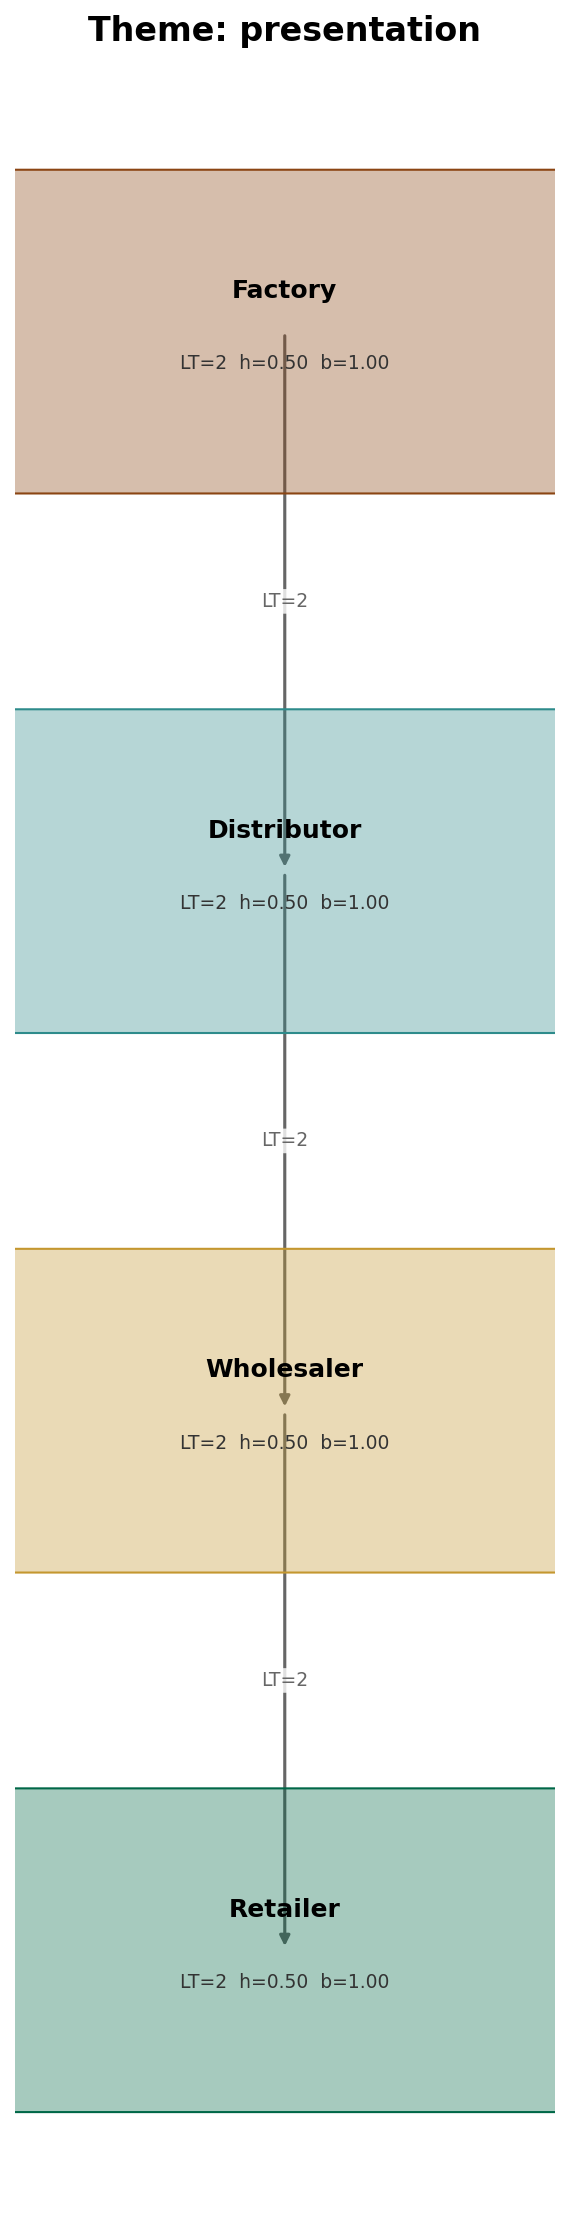

minimal: serif 8.0pt, 7.0" wide, alpha=0.0


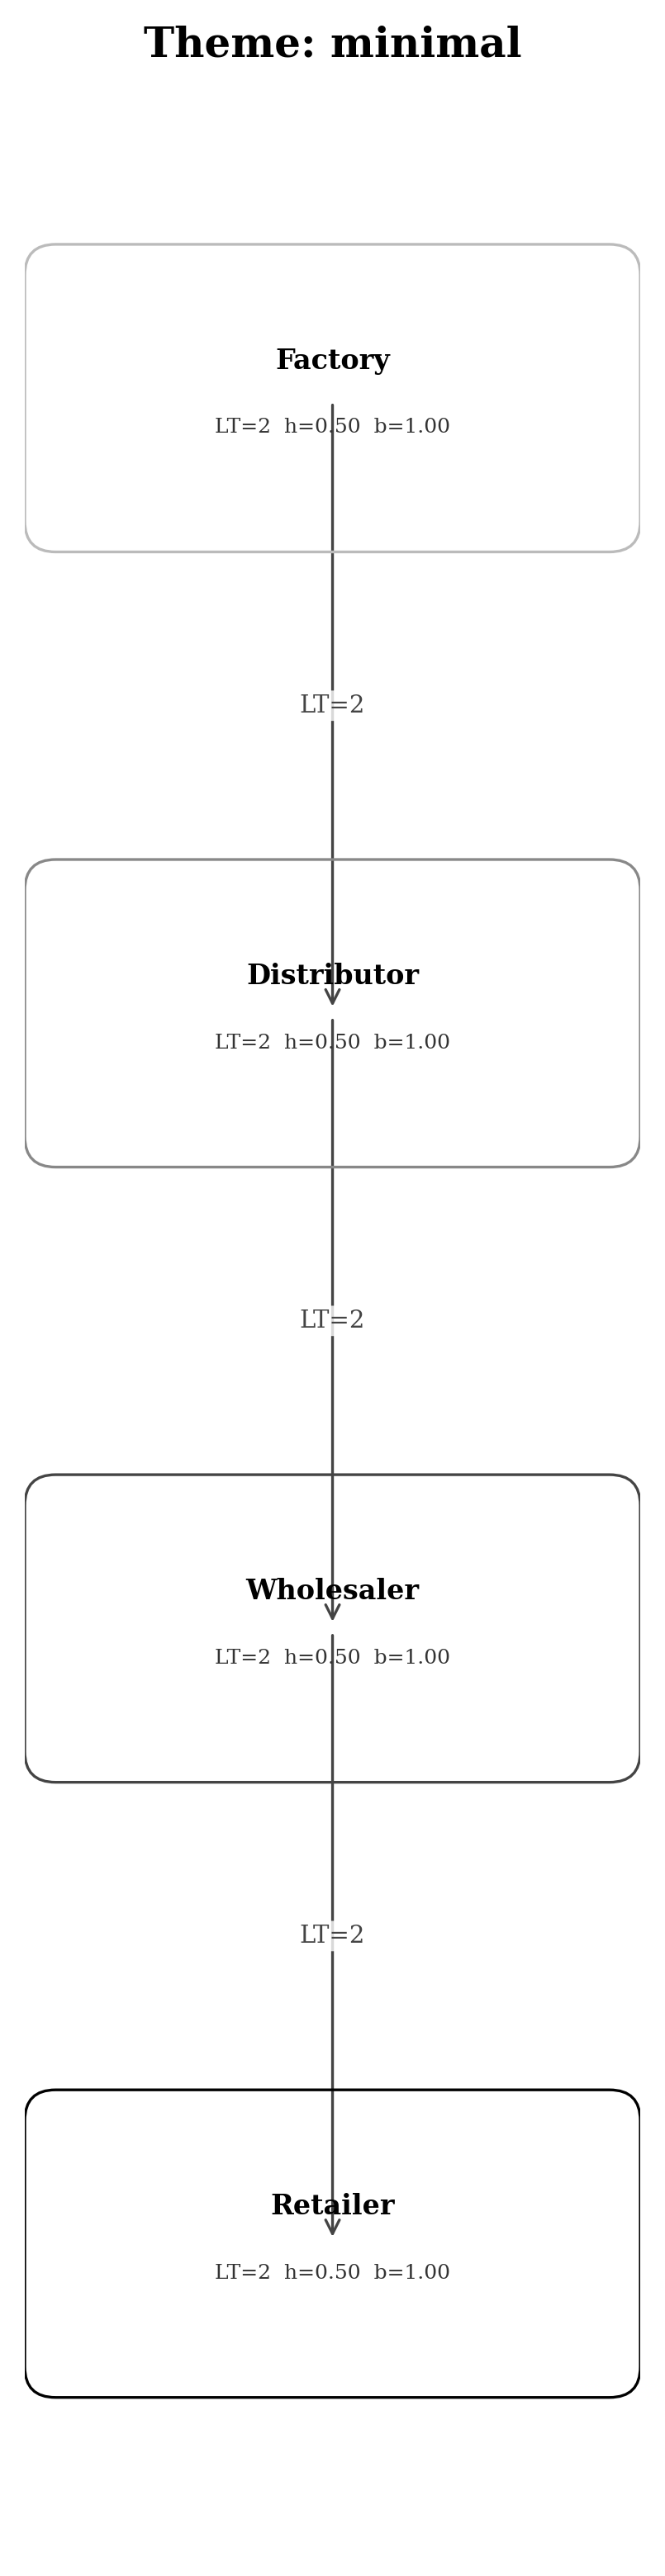

In [7]:
# Compare all 4 themes on the Beer Game
graph = from_serial(beer_game_config())

for theme_name in ["kfupm", "ieee", "presentation", "minimal"]:
    theme = get_theme(theme_name)
    fig = render_graph(graph, theme=theme_name, title=f"Theme: {theme_name}")
    print(f"{theme_name}: {theme.font.family} {theme.font.node_label_size}pt, "
          f"{theme.figure.width}\" wide, alpha={theme.node.fill_alpha}")
    plt.show()

## 3. JSON Schema — Standardized Interchange Format

Save and load supply chains in a human-readable JSON format:

In [8]:
# Serialize to JSON
json_str = to_json(
    tree,
    metadata=NetworkMetadata(
        name="Distribution Tree",
        description="Factory-Warehouse-Stores distribution network",
        author="DeepBullwhip Tutorial",
        tags=["tree", "3-tier", "distribution"],
    ),
    layout_hints={
        "Factory": NodeLayoutHint(tier=0, role="manufacturer"),
        "Warehouse": NodeLayoutHint(tier=1, role="distributor"),
        "Store_A": NodeLayoutHint(tier=2, role="retailer"),
        "Store_B": NodeLayoutHint(tier=2, role="retailer"),
    },
)
print(json_str)

{
  "version": "1.0",
  "metadata": {
    "name": "Distribution Tree",
    "description": "Factory-Warehouse-Stores distribution network",
    "author": "DeepBullwhip Tutorial",
    "created": "",
    "tags": [
      "tree",
      "3-tier",
      "distribution"
    ]
  },
  "nodes": [
    {
      "id": "Factory",
      "config": {
        "lead_time": 4,
        "holding_cost": 0.1,
        "backorder_cost": 0.4,
        "depreciation_rate": 0.0,
        "service_level": 0.95,
        "initial_inventory": 50.0
      },
      "layout": {
        "tier": 0,
        "role": "manufacturer"
      }
    },
    {
      "id": "Warehouse",
      "config": {
        "lead_time": 2,
        "holding_cost": 0.15,
        "backorder_cost": 0.5,
        "depreciation_rate": 0.0,
        "service_level": 0.95,
        "initial_inventory": 50.0
      },
      "layout": {
        "tier": 1,
        "role": "distributor"
      }
    },
    {
      "id": "Store_A",
      "config": {
        "lead_time": 

In [9]:
# Round-trip: JSON → Graph → verify
restored = from_json(json_str)
print(f"Restored nodes: {list(restored.nodes.keys())}")
print(f"Restored edges: {list(restored.edges.keys())}")
assert set(restored.nodes.keys()) == set(tree.nodes.keys())
print("Round-trip verified!")

Restored nodes: ['Factory', 'Warehouse', 'Store_A', 'Store_B']
Restored edges: [('Factory', 'Warehouse'), ('Warehouse', 'Store_A'), ('Warehouse', 'Store_B')]
Round-trip verified!


## 4. Simulation on Network Topologies

Factory       BW=1.17  FR=96%  Cost=104
Warehouse     BW=14.21  FR=33%  Cost=353
Store_A       BW=3.31  FR=100%  Cost=65
Store_B       BW=1.82  FR=100%  Cost=95


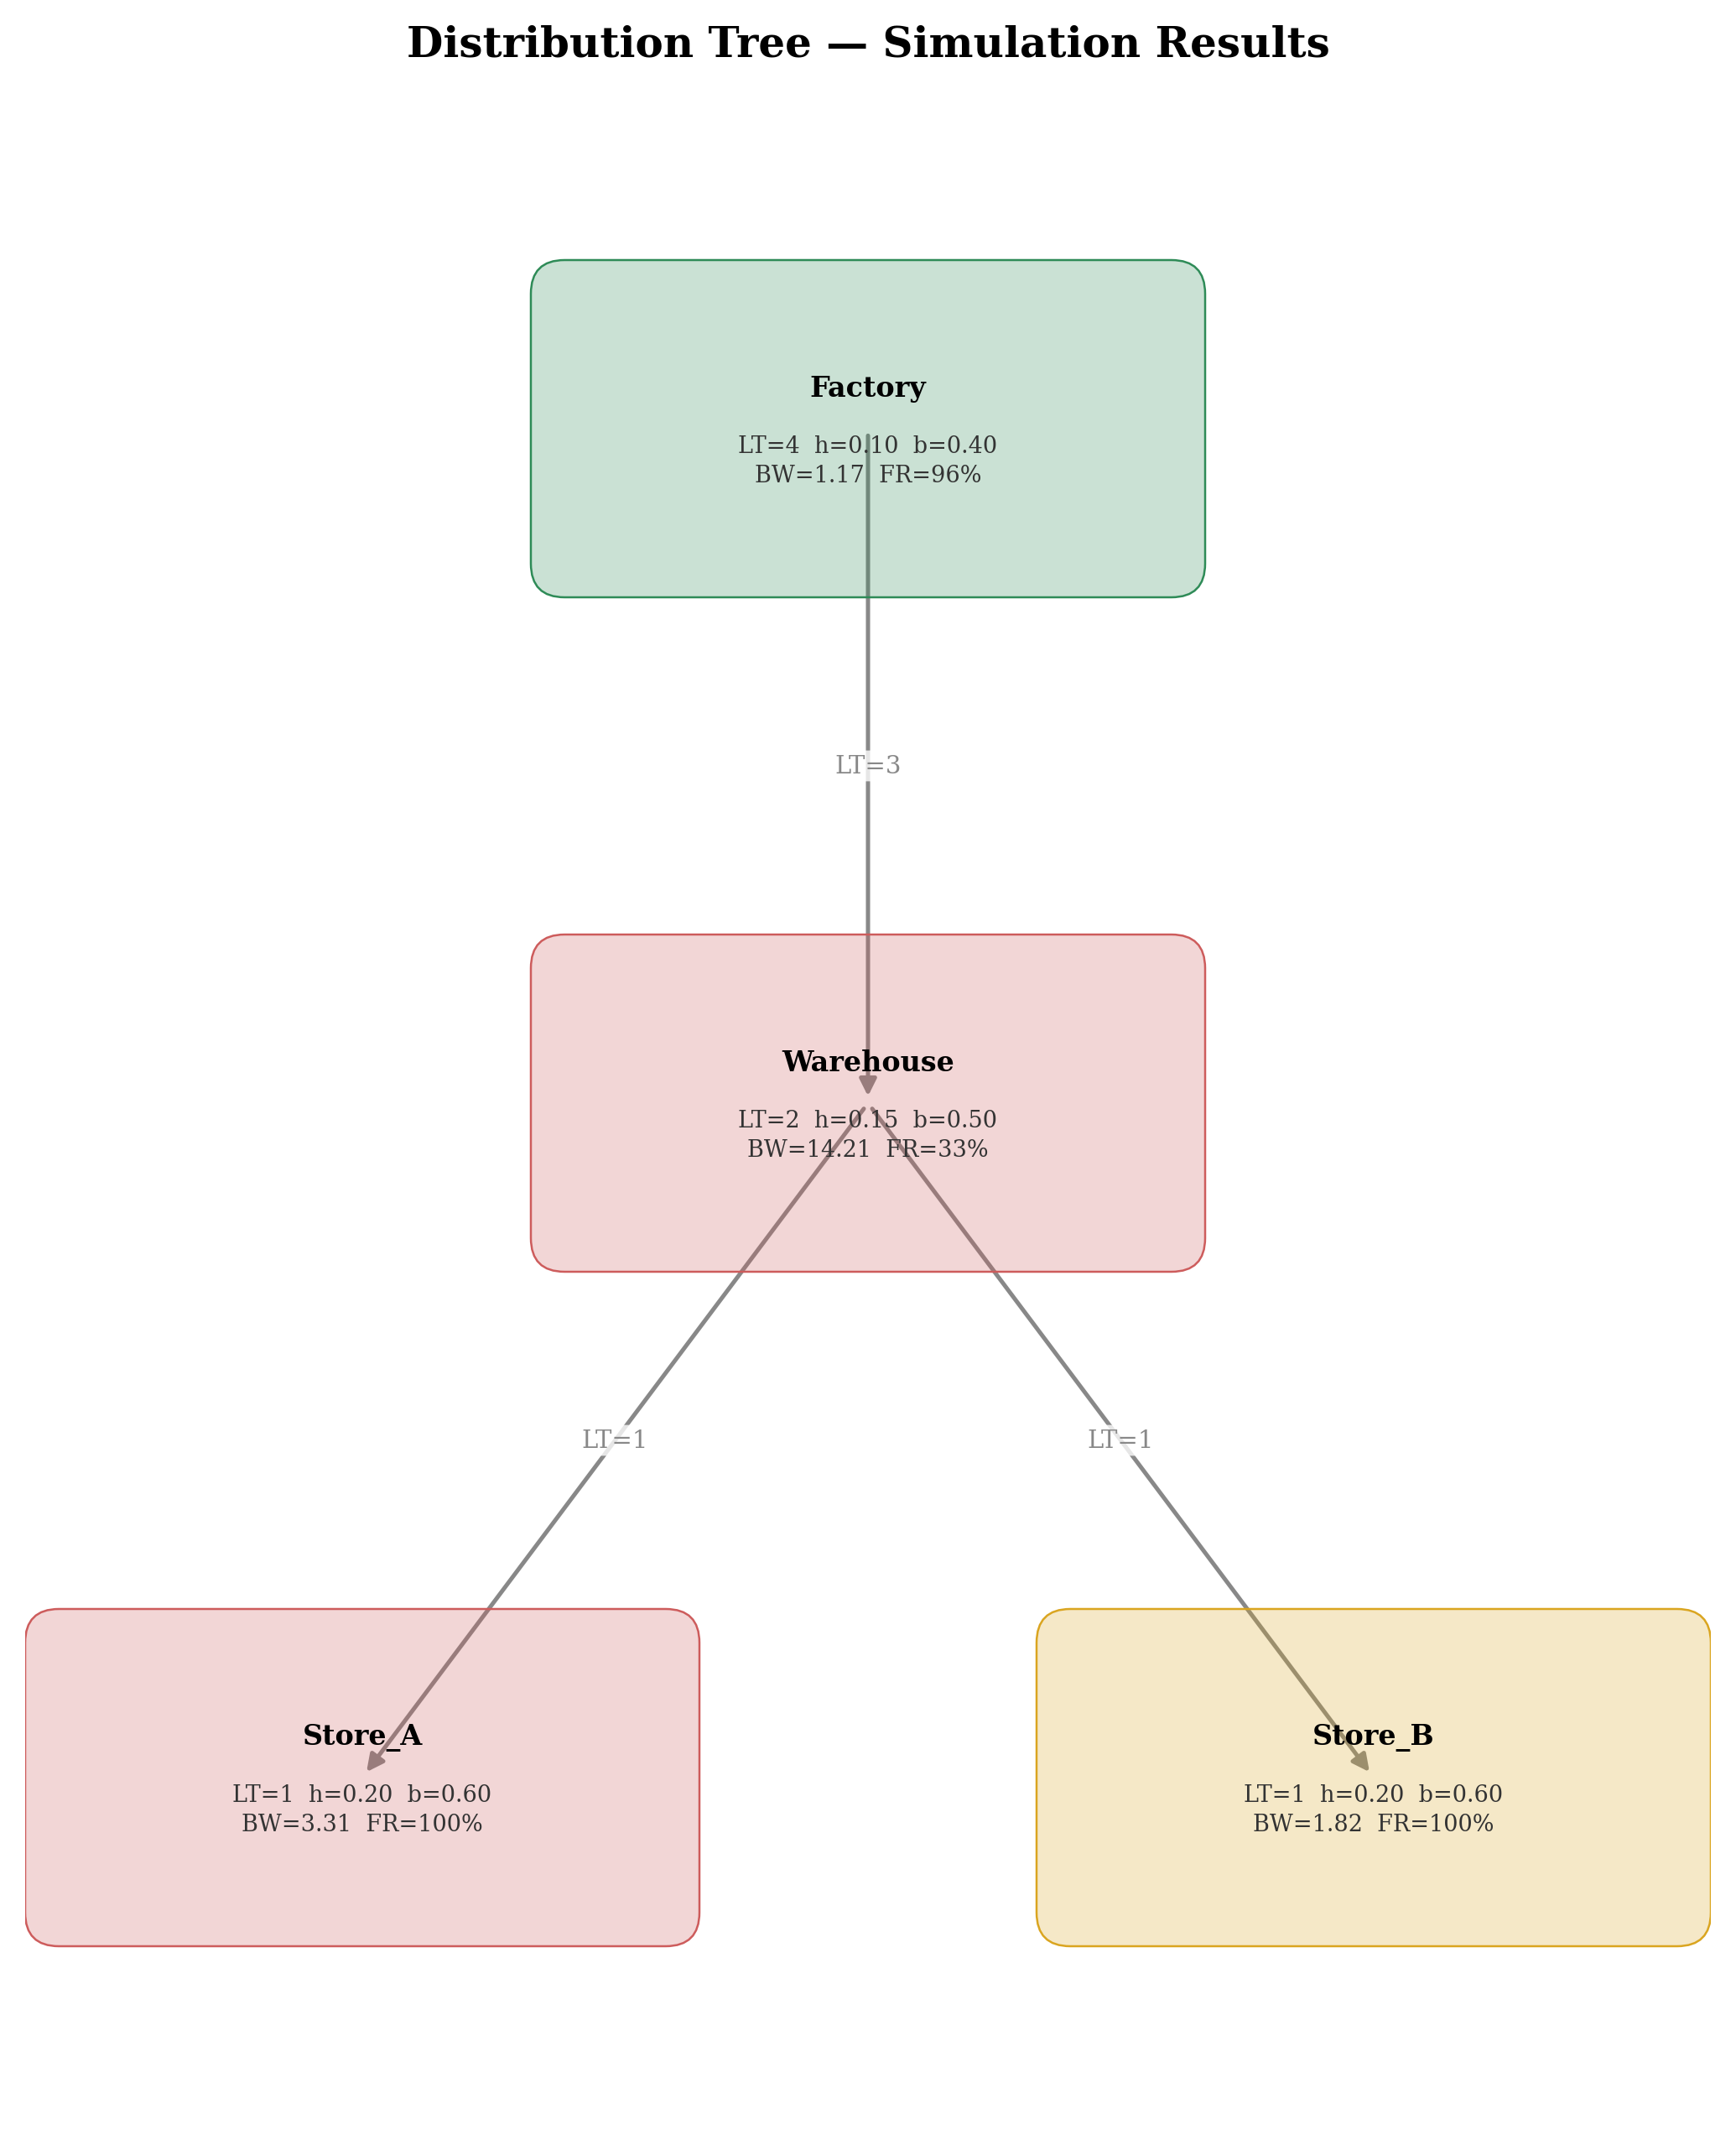

In [10]:
# Simulate the distribution tree
chain = NetworkSupplyChain(tree)
T = 52

result = chain.simulate(
    demand={"Store_A": np.full(T, 5.0), "Store_B": np.full(T, 3.0)},
    forecasts_mean={"Store_A": np.full(T, 5.0), "Store_B": np.full(T, 3.0)},
    forecasts_std={"Store_A": np.full(T, 1.0), "Store_B": np.full(T, 1.0)},
)

for name, er in result.node_results.items():
    print(f"{name:12s}  BW={er.bullwhip_ratio:.2f}  FR={er.fill_rate:.0%}  Cost={er.total_cost:,.0f}")

# Render with simulation overlay
fig = render_graph(tree, sim_result=result, theme="kfupm", title="Distribution Tree — Simulation Results")
plt.show()

## 5. TikZ Output for LaTeX Papers

Generate publication-ready TikZ code that can be directly included in LaTeX documents:

In [11]:
# Generate TikZ for IEEE paper
tex = render_graph(
    graph_4tier,
    backend="tikz",
    theme="ieee",
    title="MIT Beer Game Supply Chain",
    standalone=True,
)
print(tex[:600], "\n...\n(truncated)")


\documentclass[border=5mm]{standalone}
\usepackage[utf8]{inputenc}
\usepackage{tikz}
\usetikzlibrary{arrows.meta, positioning, calc}
\definecolor{clr555555}{HTML}{555555}
\definecolor{clr333333}{HTML}{333333}
\definecolor{clr666666}{HTML}{666666}
\definecolor{clr999999}{HTML}{999999}
\definecolor{clrBBBBBB}{HTML}{BBBBBB}
\begin{document}
\begin{tikzpicture}[
    every node/.style={
        draw,
        rounded corners=10pt,
        minimum width=1.8cm,
        minimum height=0.8cm,
        align=center,
        font=\rmfamily\fontsize{7}{5}\selectfont,
        line width=0.8pt,
    },
    ev 
...
(truncated)


## 6. Deep Dive: NetworkX Integration

DeepBullwhip integrates seamlessly with NetworkX, the standard Python graph library.
This lets you leverage NetworkX's rich ecosystem of algorithms, I/O formats, and
visualization tools while keeping DeepBullwhip's supply-chain semantics.

**Why NetworkX?**
- 100+ graph algorithms (shortest path, centrality, community detection)
- Standard graph interchange formats (GraphML, GML, JSON)
- Interoperability with igraph, graph-tool, PyVis, and more

### 6.1 Bidirectional Conversion

Convert any `SupplyChainGraph` to a NetworkX `DiGraph` and back losslessly:

In [12]:
import networkx as nx
from deepbullwhip import to_networkx, from_networkx, serial_to_networkx

# Convert our convergent network to NetworkX
G = to_networkx(convergent)

print(f"Type: {type(G)}")
print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")
print(f"Is DAG: {nx.is_directed_acyclic_graph(G)}")
print()

# Node attributes are preserved from EchelonConfig
for node, attrs in G.nodes(data=True):
    print(f"  {node}: LT={attrs['lead_time']}, h={attrs['holding_cost']}, b={attrs['backorder_cost']}")

Type: <class 'networkx.classes.digraph.DiGraph'>
Nodes: 4, Edges: 3
Is DAG: True

  Chip_Supplier: LT=8, h=0.05, b=0.3
  PCB_Supplier: LT=6, h=0.04, b=0.25
  Assembler: LT=3, h=0.12, b=0.5
  Retailer: LT=1, h=0.2, b=0.8


In [13]:
# Round-trip: convert back to SupplyChainGraph
graph_restored = from_networkx(G)
print(f"Restored nodes: {list(graph_restored.nodes.keys())}")
print(f"Restored edges: {list(graph_restored.edges.keys())}")
assert set(graph_restored.nodes.keys()) == set(convergent.nodes.keys())
print("NetworkX round-trip OK!")

# Convenience: serial config list → NetworkX directly
G_beer = serial_to_networkx(beer_game_config())
print(f"\nBeer Game DiGraph: {G_beer.number_of_nodes()} nodes, {G_beer.number_of_edges()} edges")

Restored nodes: ['Chip_Supplier', 'PCB_Supplier', 'Assembler', 'Retailer']
Restored edges: [('Chip_Supplier', 'Assembler'), ('PCB_Supplier', 'Assembler'), ('Assembler', 'Retailer')]
NetworkX round-trip OK!

Beer Game DiGraph: 4 nodes, 3 edges


### 6.2 Supply Chain Graph Analysis

DeepBullwhip wraps NetworkX algorithms with supply-chain-meaningful semantics:

| Function | What it tells you | Why it matters |
|----------|-------------------|----------------|
| `find_critical_path(G)` | Longest lead-time path | End-to-end replenishment delay |
| `critical_path_length(G)` | Total critical lead time | Planning horizon for safety stock |
| `echelon_centrality(G)` | Bottleneck nodes | Disruption risk assessment |
| `upstream_nodes(G, n)` | All suppliers of node n | Impact analysis for supplier failures |
| `downstream_nodes(G, n)` | All customers of node n | Demand propagation scope |
| `topological_order(G)` | Simulation execution order | How material flows through the chain |

In [14]:
from deepbullwhip.network import (
    find_critical_path, echelon_centrality,
    upstream_nodes, downstream_nodes, topological_order,
)
from deepbullwhip.network.analysis import critical_path_length

G = to_networkx(convergent)

# Critical path: which supply route takes the longest?
print("=== Critical Path Analysis ===")
path = find_critical_path(G)
length = critical_path_length(G)
print(f"Critical path: {' → '.join(path)}")
print(f"Total critical lead time: {length} periods")
print(f"  (This means a disruption at {path[0]} takes {length} periods to reach {path[-1]})")
print()

# Centrality: which node is the biggest bottleneck?
print("=== Bottleneck Analysis (Betweenness Centrality) ===")
centrality = echelon_centrality(G)
bottleneck = max(centrality, key=centrality.get)
for name, score in sorted(centrality.items(), key=lambda x: -x[1]):
    marker = " ← BOTTLENECK" if name == bottleneck else ""
    print(f"  {name}: {score:.3f}{marker}")
print()

# Supplier impact: if Chip_Supplier goes down, who is affected?
print("=== Supplier Impact Analysis ===")
affected = downstream_nodes(G, "Chip_Supplier")
print(f"If Chip_Supplier fails, affected nodes: {affected}")
print()

# What does the Retailer depend on?
suppliers = upstream_nodes(G, "Retailer")
print(f"Retailer depends on: {suppliers}")
print()

# Simulation order
print("=== Simulation Execution Order ===")
order = topological_order(G)
print(f"Process order: {' → '.join(order)}")
print("  (Material flows from left to right, upstream first)")

=== Critical Path Analysis ===
Critical path: Chip_Supplier → Assembler → Retailer
Total critical lead time: 7 periods
  (This means a disruption at Chip_Supplier takes 7 periods to reach Retailer)

=== Bottleneck Analysis (Betweenness Centrality) ===
  Assembler: 0.333 ← BOTTLENECK
  Chip_Supplier: 0.000
  PCB_Supplier: 0.000
  Retailer: 0.000

=== Supplier Impact Analysis ===
If Chip_Supplier fails, affected nodes: {'Retailer', 'Assembler'}

Retailer depends on: {'Chip_Supplier', 'PCB_Supplier', 'Assembler'}

=== Simulation Execution Order ===
Process order: Chip_Supplier → PCB_Supplier → Assembler → Retailer
  (Material flows from left to right, upstream first)


### 6.3 Building Supply Chains from NetworkX

You can also build a supply chain starting from a NetworkX graph.
This is useful when your network topology comes from another source (e.g., a GIS system, a database, or another modeling tool):

Simulation from NetworkX graph:
  Mines       BW=6.40  FR=65%
  Refinery    BW=12.48  FR=77%
  Plant       BW=5.39  FR=88%
  DC          BW=2.93  FR=98%


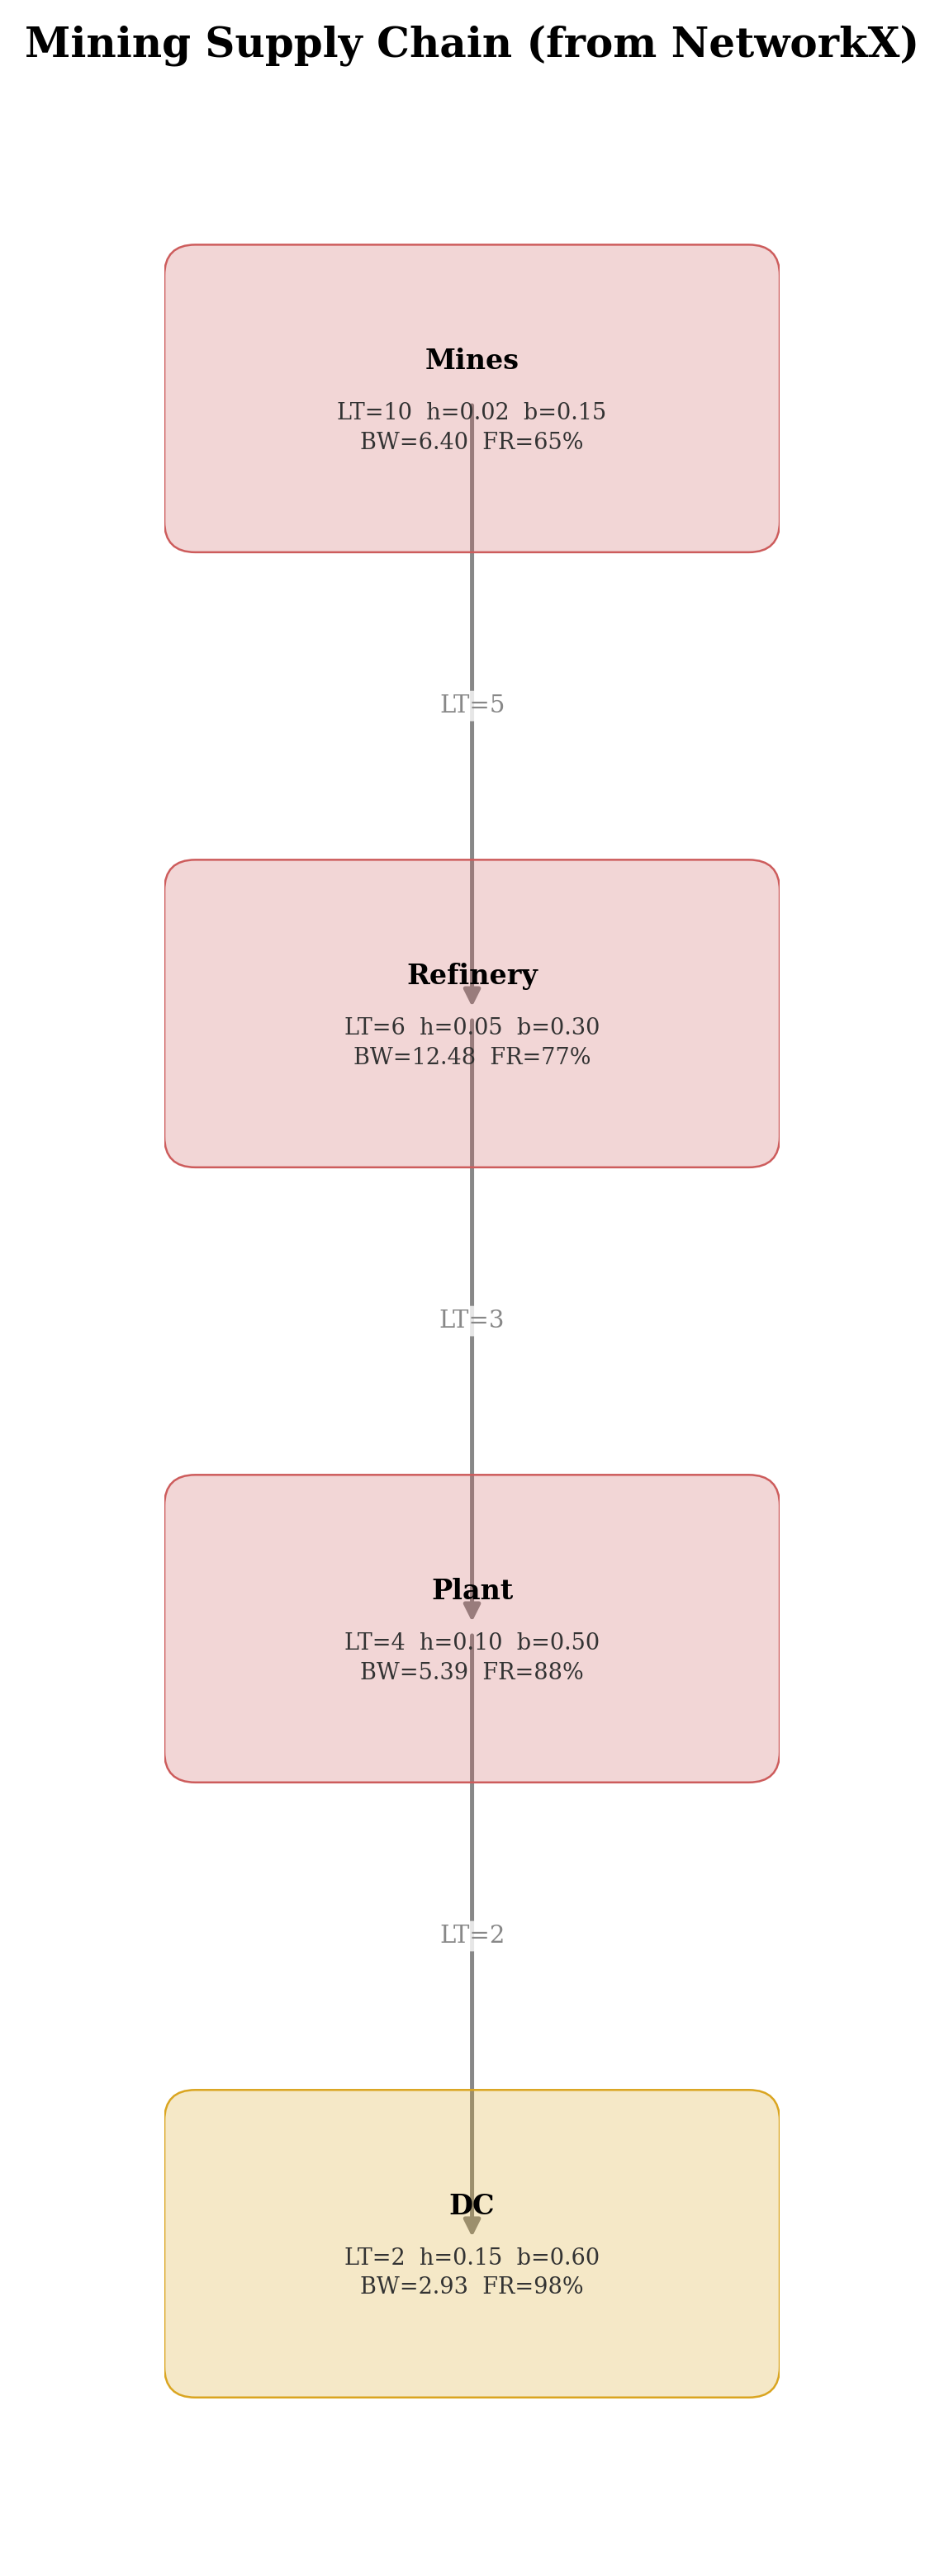

In [15]:
# Build a supply chain from scratch using NetworkX
G_custom = nx.DiGraph()

# Add nodes with supply chain attributes
G_custom.add_node("Mines", lead_time=10, holding_cost=0.02, backorder_cost=0.15)
G_custom.add_node("Refinery", lead_time=6, holding_cost=0.05, backorder_cost=0.30)
G_custom.add_node("Plant", lead_time=4, holding_cost=0.10, backorder_cost=0.50)
G_custom.add_node("DC", lead_time=2, holding_cost=0.15, backorder_cost=0.60)

# Add edges with lead times
G_custom.add_edge("Mines", "Refinery", lead_time=5)
G_custom.add_edge("Refinery", "Plant", lead_time=3)
G_custom.add_edge("Plant", "DC", lead_time=2)

# Convert to DeepBullwhip and simulate
chain = NetworkSupplyChain.from_networkx(G_custom)

T = 52
demand = np.maximum(np.random.default_rng(42).normal(10, 2, T), 0)
result = chain.simulate(
    demand={"DC": demand},
    forecasts_mean={"DC": np.full(T, 10.0)},
    forecasts_std={"DC": np.full(T, 2.0)},
)

print("Simulation from NetworkX graph:")
for name, er in result.node_results.items():
    print(f"  {name:10s}  BW={er.bullwhip_ratio:.2f}  FR={er.fill_rate:.0%}")

# Visualize the result using our renderer
graph_from_nx = from_networkx(G_custom)
fig = render_graph(graph_from_nx, sim_result=result, theme="kfupm", title="Mining Supply Chain (from NetworkX)")
plt.show()

### 6.4 Using Native NetworkX Algorithms

Since `to_networkx()` returns a standard `nx.DiGraph`, you can use **any** NetworkX algorithm directly. Here are some examples relevant to supply chain analysis:

In [16]:
# Use ANY NetworkX algorithm on your supply chain
G = to_networkx(convergent)

# 1. Shortest path (weighted by lead time) — fastest supply route
shortest = nx.shortest_path(G, "Chip_Supplier", "Retailer", weight="lead_time")
shortest_length = nx.shortest_path_length(G, "Chip_Supplier", "Retailer", weight="lead_time")
print(f"Fastest route Chip→Retailer: {' → '.join(shortest)} ({shortest_length} periods)")

# 2. All simple paths — enumerate all possible supply routes
all_paths = list(nx.all_simple_paths(G, "Chip_Supplier", "Retailer"))
print(f"All paths from Chip_Supplier to Retailer: {all_paths}")

# 3. In-degree / out-degree — supply chain fan-in/fan-out
print("\nFan-in / Fan-out:")
for node in G.nodes:
    print(f"  {node}: in-degree={G.in_degree(node)} (suppliers), out-degree={G.out_degree(node)} (customers)")

# 4. Export to standard formats for other tools
node_link = nx.node_link_data(G)  # JSON-compatible dict
print(f"\nJSON node_link_data has {len(node_link['nodes'])} nodes, {len(node_link['edges'])} links")
# nx.write_graphml(G, "convergent.graphml")  # for Gephi, yEd, etc.

Fastest route Chip→Retailer: Chip_Supplier → Assembler → Retailer (7 periods)
All paths from Chip_Supplier to Retailer: [['Chip_Supplier', 'Assembler', 'Retailer']]

Fan-in / Fan-out:
  Chip_Supplier: in-degree=0 (suppliers), out-degree=1 (customers)
  PCB_Supplier: in-degree=0 (suppliers), out-degree=1 (customers)
  Assembler: in-degree=2 (suppliers), out-degree=1 (customers)
  Retailer: in-degree=1 (suppliers), out-degree=0 (customers)

JSON node_link_data has 4 nodes, 3 links


---

## Next Steps

- **Optimization**: See [`05_pyomo_optimization.ipynb`](05_pyomo_optimization.ipynb) for supply chain optimization with Pyomo (service level tuning, inventory optimization, network design).
- **Custom policies**: See [`03_custom_policies.ipynb`](03_custom_policies.ipynb) for extending the framework with custom ordering policies and cost functions.
- **Benchmarking**: See [`06_benchmark_policies.ipynb`](06_benchmark_policies.ipynb) for comparing policies across demand patterns.